In [ ]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.8/366.8 kB 26.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ananyaaas","key":"52cc18e13eab3da2b5f4a1ff1a6f4b7e"}'}

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
!kaggle datasets download -d cmacus/malaria-parasite-in-blood-smears
!unzip malaria-parasite-in-blood-smears.zip -d malaria_dataset

Dataset URL: https://www.kaggle.com/datasets/cmacus/malaria-parasite-in-blood-smears
License(s): copyright-authors
 96% 143M/149M [00:00<00:00, 765MB/s] 
100% 149M/149M [00:00<00:00, 672MB/s]
Archive:  malaria-parasite-in-blood-smears.zip
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120342.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120502.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120528.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120551.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120555.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120626.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120648.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120715.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/190813120743.png  
  inflating: malaria_dataset/malaria_image_dataset/malaria/

In [ ]:
# Cell 1 - Import libraries & set dataset path
import os

dataset_path = "/content/malaria_dataset/malaria_image_dataset"
categories = ["malaria", "no_malaria"]

# Check folder structure
for category in categories:
    print(f"{category} → {len(os.listdir(os.path.join(dataset_path, category)))} images")


malaria → 100 images
no_malaria → 100 images


In [ ]:
# Cell 1 - Import libraries & set dataset path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pywt

# Fix for scikit-image import changes (grey vs gray)
try:
    from skimage.feature import graycomatrix as greycomatrix, graycoprops as greycoprops
except ImportError:
    from skimage.feature import greycomatrix, greycoprops

# Dataset path (adjusted based on your screenshot)
dataset_path = "/content/malaria_dataset/malaria_image_dataset"
MALARIA_DIR = os.path.join(dataset_path, "malaria")
NO_MALARIA_DIR = os.path.join(dataset_path, "no_malaria")

# Quick check
print("Malaria images:", len(os.listdir(MALARIA_DIR)))
print("No_Malaria images:", len(os.listdir(NO_MALARIA_DIR)))


Malaria images: 100
No_Malaria images: 100


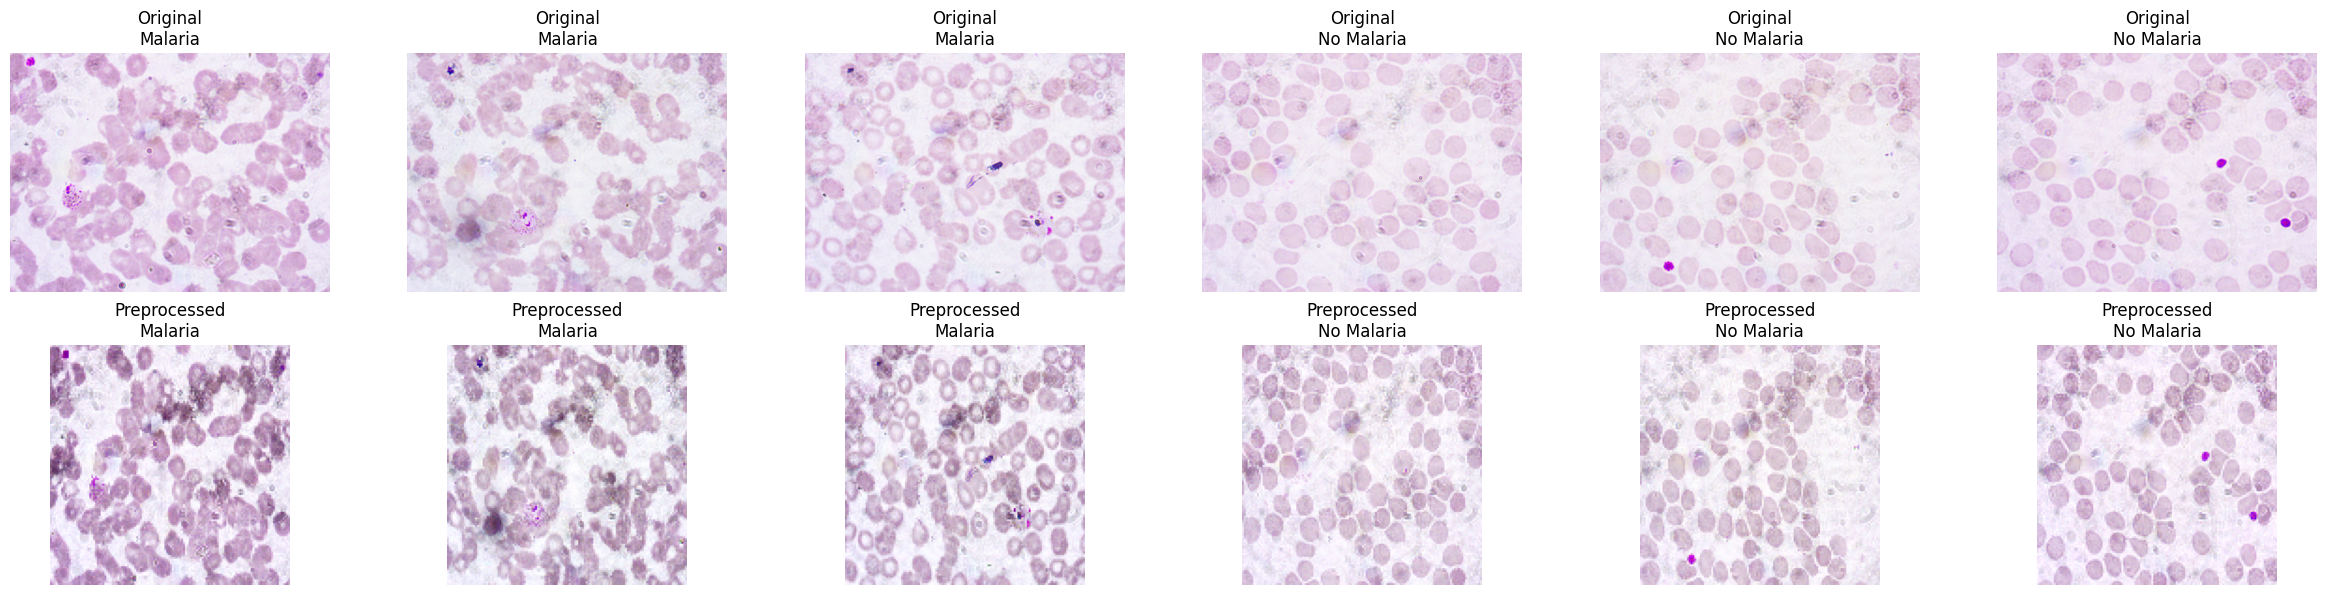

In [ ]:
# Cell 2 - Preprocessing (High Resolution, Clear RBCs)

IMG_SIZE = 128  # use 128 instead of 64 for clarity (can also try 224)

def preprocess_image_better(img_bgr, img_size=IMG_SIZE):
    # Convert BGR -> RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_CUBIC)

    # Contrast enhancement with CLAHE
    lab = cv2.cvtColor(img_resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l2 = clahe.apply(l)
    lab = cv2.merge((l2, a, b))
    img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # ✅ Remove Gaussian blur & strong denoising (keeps parasites sharp)
    img_final = img_clahe.copy()

    # Normalize [0,1]
    img_norm = img_final.astype(np.float32) / 255.0
    return img_norm

# Show few samples
def show_samples(n=3):
    malaria_files = sorted(glob(os.path.join(MALARIA_DIR, "*")))[:n]
    no_files = sorted(glob(os.path.join(NO_MALARIA_DIR, "*")))[:n]

    files = malaria_files + no_files
    labels = ["Malaria"]*len(malaria_files) + ["No Malaria"]*len(no_files)

    fig, axes = plt.subplots(2, len(files), figsize=(4*len(files), 6))
    for i, f in enumerate(files):
        orig = cv2.imread(f)
        pre = preprocess_image_better(orig)

        axes[0,i].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Original\n{labels[i]}")

        axes[1,i].imshow(pre)
        axes[1,i].axis('off')
        axes[1,i].set_title(f"Preprocessed\n{labels[i]}")

    plt.tight_layout()
    plt.show()

show_samples(3)


In [ ]:
# Cell 3 - Feature Extraction (Wavelet + Texture + Shape)

def extract_features(img):
    features = []

    # --- Wavelet features ---
    coeffs2 = pywt.dwt2(cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY), 'haar')
    cA, (cH, cV, cD) = coeffs2
    features.extend([cA.mean(), cH.mean(), cV.mean(), cD.mean()])
    features.extend([cA.std(), cH.std(), cV.std(), cD.std()])

    # --- Texture features (GLCM) ---
    gray = (cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
    glcm = greycomatrix(gray, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        features.append(np.mean(greycoprops(glcm, prop)))

    # --- Shape features (Contour Area, Perimeter) ---
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
    else:
        area, perimeter = 0, 0
    features.extend([area, perimeter])

    return np.array(features)

# Build dataset
X, y = [], []
for label, folder in [(1, MALARIA_DIR), (0, NO_MALARIA_DIR)]:
    files = glob(os.path.join(folder, "*"))
    for f in files[:500]:   # limit to 500 per class for speed (adjust as needed)
        img = cv2.imread(f)
        if img is not None:
            pre = preprocess_image_better(img)
            feat = extract_features(pre)
            X.append(feat)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (200, 16)
Labels shape: (200,)


Original shape: (200, 16)
After PCA shape: (200, 10)
Training samples: 160
Testing samples: 40

Accuracy (Random Forest): 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.68      0.75      0.71        20

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



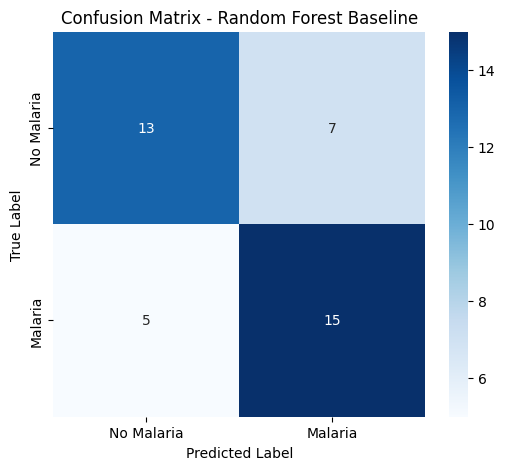

In [ ]:
# Cell 4 - Feature Optimization (PCA) + Train/Test Split + Classical Baseline

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the max number of features we can use
max_features = X_scaled.shape[1]

# Dimensionality reduction (PCA)
pca = PCA(n_components=min(10, max_features))  # choose <= available features
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("After PCA shape:", X_pca.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Classical baseline classifier (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluation
print("\nAccuracy (Random Forest):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Malaria", "Malaria"],
            yticklabels=["No Malaria", "Malaria"])
plt.title("Confusion Matrix - Random Forest Baseline")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [ ]:
# Cell 5 - Variational Quantum Classifier (3-step test, fixed MAXFUN)

!pip install qiskit qiskit-aer qiskit-machine-learning

from qiskit_aer import AerSimulator
from qiskit.circuit.library import ZZFeatureMap, TwoLocal
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.primitives import Sampler
from scipy.optimize import minimize

# Custom optimizer with progress tracking using maxfun
def cobyla_optimizer(fun, x0, **kwargs):
    history = []

    def callback(xk):
        val = fun(xk)
        history.append(val)
        print(f"Step {len(history)} - Cost: {val:.4f}")

    num_vars = len(x0)
    res = minimize(fun, x0, method="COBYLA",
                   options={'maxfun': num_vars * 3},  # ~3 steps
                   callback=callback)
    return res.x, res.fun, res.nit

# Use PCA reduced dataset
X_train_q, X_test_q = X_train, X_test
y_train_q, y_test_q = y_train, y_test

# Quantum feature map (simplified)
feature_map = ZZFeatureMap(feature_dimension=X_train_q.shape[1], reps=1)

# Variational ansatz (simplified)
ansatz = TwoLocal(feature_map.num_qubits, ['ry','rz'], 'cz', reps=1, entanglement='full')

# Backend & Sampler
backend = AerSimulator()
sampler = Sampler()

# Define VQC
vqc = VQC(feature_map=feature_map,
          ansatz=ansatz,
          optimizer=cobyla_optimizer,
          sampler=sampler)

print("Training Variational Quantum Classifier (≈3 steps)...")
vqc.fit(X_train_q, y_train_q)

# Test
y_pred_q = vqc.predict(X_test_q)

# Evaluation
print("\nAccuracy (Quantum VQC, test run):", accuracy_score(y_test_q, y_pred_q))
print("\nClassification Report:\n", classification_report(y_test_q, y_pred_q))

# Confusion Matrix
cm_q = confusion_matrix(y_test_q, y_pred_q)
plt.figure(figsize=(6,5))
sns.heatmap(cm_q, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Malaria", "Malaria"],
            yticklabels=["No Malaria", "Malaria"])
plt.title("Confusion Matrix - VQC (Test Run)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


/tmp/ipython-input-3070634237.py:38: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()
/tmp/ipython-input-3070634237.py:21: OptimizeWarning: Unknown solver options: maxfun
  res = minimize(fun, x0, method="COBYLA",


Training Variational Quantum Classifier (≈3 steps)...
Step 1 - Cost: 0.9900
Step 2 - Cost: 0.9900
Step 3 - Cost: 0.9899
Step 4 - Cost: 0.9899
Step 5 - Cost: 0.9877
Step 6 - Cost: 0.9876
Step 7 - Cost: 0.9876
Step 8 - Cost: 0.9876
Step 9 - Cost: 0.9861
Step 10 - Cost: 0.9861
Step 11 - Cost: 0.9851
Step 12 - Cost: 0.9851
Step 13 - Cost: 0.9851
Step 14 - Cost: 0.9851
Step 15 - Cost: 0.9851
Step 16 - Cost: 0.9851
Step 17 - Cost: 0.9851
Step 18 - Cost: 0.9851
Step 19 - Cost: 0.9851
Step 20 - Cost: 0.9851
Step 21 - Cost: 0.9851
Step 22 - Cost: 0.9851
Step 23 - Cost: 0.9851
Step 24 - Cost: 0.9851
Step 25 - Cost: 0.9851
Step 26 - Cost: 0.9851
Step 27 - Cost: 0.9851
Step 28 - Cost: 0.9851
Step 29 - Cost: 0.9851
Step 30 - Cost: 0.9851
Step 31 - Cost: 0.9851
Step 32 - Cost: 0.9851
Step 33 - Cost: 0.9851
Step 34 - Cost: 0.9851
Step 35 - Cost: 0.9851
Step 36 - Cost: 0.9851
Step 37 - Cost: 0.9851
Step 38 - Cost: 0.9851
Step 39 - Cost: 0.9851
Step 40 - Cost: 0.9850
Step 41 - Cost: 0.9849
Step 42 - Co

AttributeError: nit